In [1]:
import shap
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Charger le modèle et les données
xgb_model = joblib.load('../models/xgboost_final.pkl')

(X_train, X_val, X_test,
 y_train, y_val, y_test,
 scaler, feature_names) = joblib.load('../data/processed/splits.pkl')

print('Modèle et données chargés')
print(f'Val set : {X_val.shape}')

Modèle et données chargés
Val set : (323, 32)


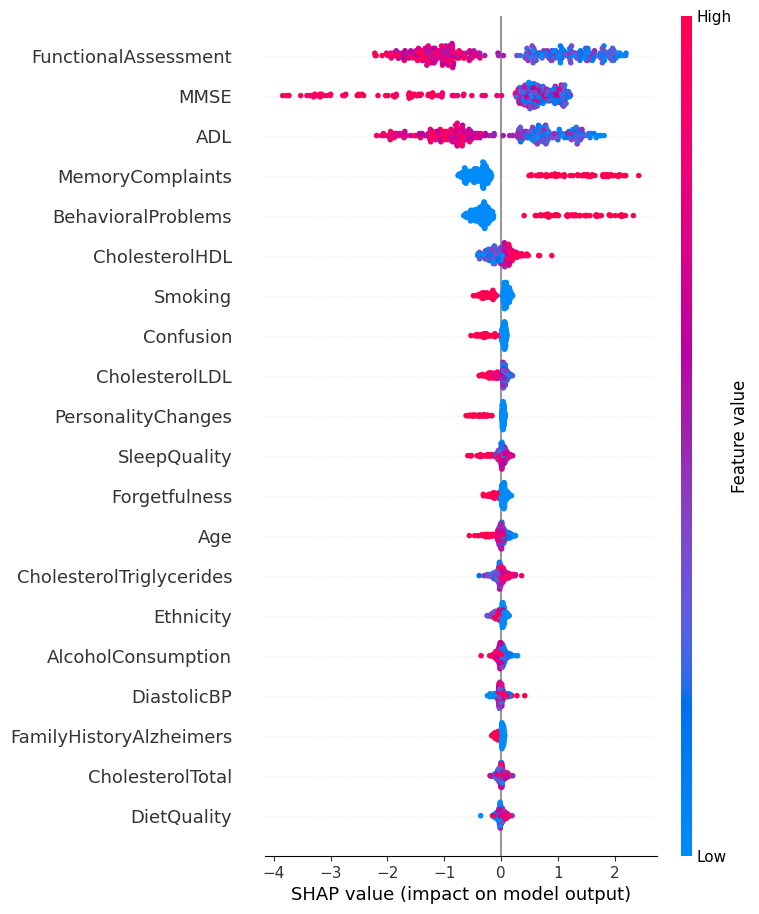

SHAP OK


In [4]:
# Explainer version moderne
explainer = shap.Explainer(xgb_model, X_val)
shap_values = explainer(X_val)

shap.summary_plot(shap_values, X_val,
                  feature_names=feature_names,
                  show=False)
plt.tight_layout(pad=2.0)
plt.savefig('../reports/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('SHAP OK')

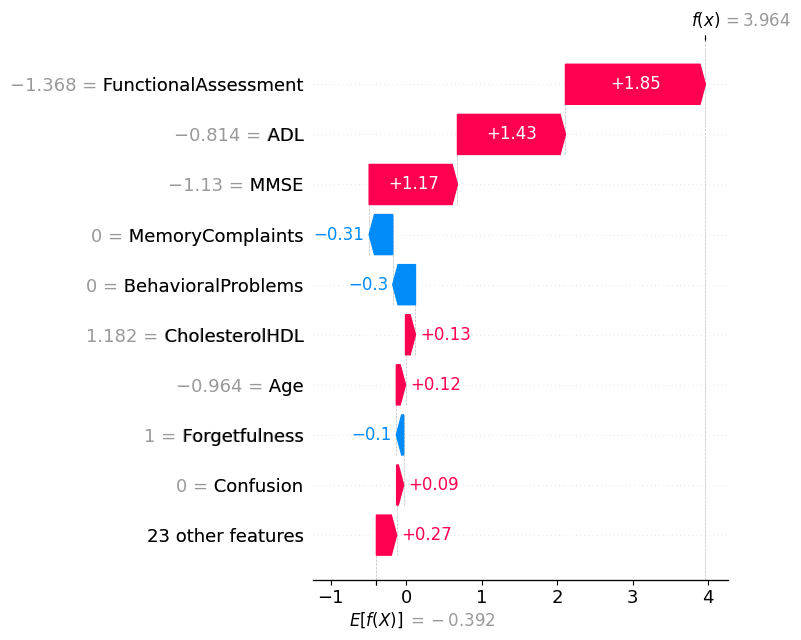

Patient — Diagnostic réel : Alzheimer


In [5]:
# Cas 1 — patient Alzheimer
idx_alz = y_val[y_val == 1].index[0]
patient = X_val.loc[[idx_alz]]

shap.waterfall_plot(shap_values[X_val.index.get_loc(idx_alz)], show=False)
plt.tight_layout()
plt.savefig('../reports/shap_patient_alzheimer.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Patient — Diagnostic réel : Alzheimer')

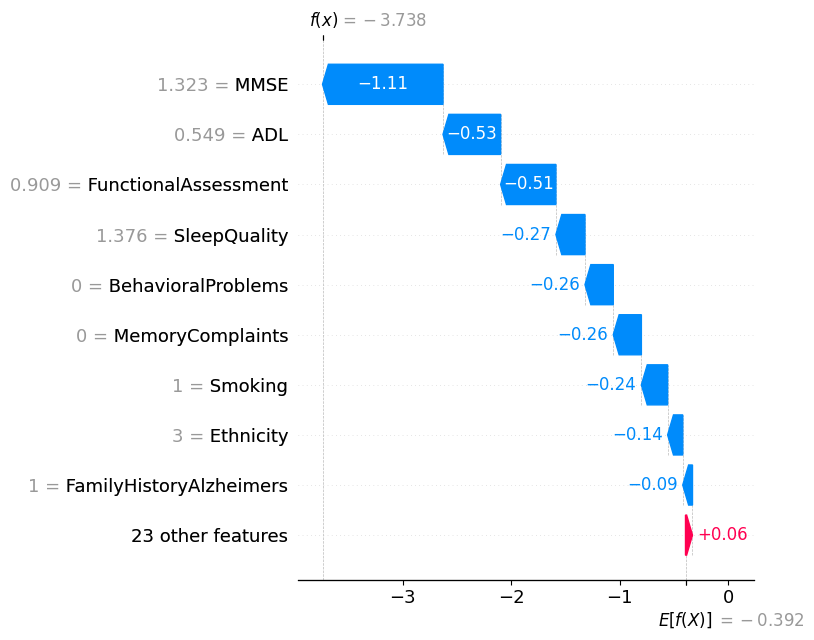

Patient — Diagnostic réel : Non-Alzheimer


In [6]:
# Cas 2 — patient Non-Alzheimer
idx_no = y_val[y_val == 0].index[0]

shap.waterfall_plot(shap_values[X_val.index.get_loc(idx_no)], show=False)
plt.tight_layout()
plt.savefig('../reports/shap_patient_non_alzheimer.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Patient — Diagnostic réel : Non-Alzheimer')